In [2]:
import pandas as pd

# Cargar data preprocesada:
data_p = pd.read_csv('../Data/Processed/Flujo_Vehicular_procesado.csv', encoding='latin-1')

data_p.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,ANIO,MES,PERIODO,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO
0,7.649693,8.996033,7.858254,7.772753,6.580639,5.755742,8.164226,8.0,2014.0,1.0,201401.0,Concesionado,22PE5NACS1,San Martín
1,0.000000,10.112329,8.780019,8.438799,7.411556,8.015988,9.072457,213.0,2014.0,1.0,201401.0,Concesionado,04PE1SCAM1,Arequipa
2,10.423590,11.316180,9.797127,8.576970,7.048386,7.460490,8.583543,12.0,2014.0,1.0,201401.0,Concesionado,21PE3SCRO1,Puno
3,2.397895,10.756732,9.739909,9.830164,8.403801,8.025843,9.873080,135.0,2014.0,1.0,201401.0,Concesionado,12PE3NCRA1,Junín
4,0.000000,10.078784,8.457443,8.279443,6.104793,6.646391,8.280458,95.0,2014.0,1.0,201401.0,Concesionado,08PE3SCSC1,Cusco


In [3]:
data_p.columns

Index(['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS__2E',
       'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E',
       'VEH_PESADOS_7E', 'ANIO', 'MES', 'PERIODO', 'ADMINIST', 'CODIGO_PEAJE',
       'DEPARTAMENTO'],
      dtype='object')

In [4]:
# Separamos las el dataset de entrenamiento y validacion
from sklearn.model_selection import train_test_split

targets = ['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS__2E',
       'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E',
       'VEH_PESADOS_7E']

X = data_p.drop(targets, axis=1)
y = data_p[targets]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
df_num = X_test.select_dtypes(include=['number', 'int', 'float'])
df_cat = X_test.select_dtypes(include=['object'])

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
import numpy as np
import warnings 

warnings.filterwarnings("ignore")

preprocessor = ColumnTransformer(
    transformers=[
        #("num", StandardScaler(), list(df_num.columns)),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"), list(df_cat.columns)),
    ])

X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

for t in targets:
    y_train[t] = y_train[t].apply(np.log1p)
    y_test[t] = y_test[t].apply(np.log1p)

In [7]:
# Entrenamiento de los modelos
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

# Pipeline base
pipe_model = Pipeline([
    ('scaler', 'Passthrough'),
    ('model', LinearRegression())
])

# Generamos los parametros a probar en paramgrid
param_grid = [
    {
        'model': [LinearRegression()],
        'scaler' : [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    {
        'model': [RandomForestRegressor()],
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 10, 20, 30],
        'scaler' : ['passthrough']
    },
    {
        'model': [XGBRegressor()],
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 10, 20, 30],
        'scaler' : ['passthrough']
    },
    {
        'model': [SVR()],
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf'],
        'scaler' : [StandardScaler(), MinMaxScaler()]
    }
]

grid = GridSearchCV(pipe_model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

grid.fit(X_train_pre, y_train)

best_model = grid.best_estimator_
y_pred_log = best_model.predict(X_test_pre)

y_pred_final = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test) # El original sin logaritmo

print(f"Mejor Modelo: {grid.best_params_['model']}")

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_final))
print(f"RMSE: {rmse:.2f}")

mae = mean_absolute_error(y_test_original, y_pred_final)
print(f"MAE:  {mae:.2f}")

r2 = r2_score(y_test_original, y_pred_final)
print(f"R2:   {r2:.4f}")

mape = mean_absolute_percentage_error(y_test_original, y_pred_final)
print(f"MAPE: {mape * 100:.2f}%")

Mejor Modelo: RandomForestRegressor()
RMSE: 99.53
MAE:  16.67
R2:   0.2629
MAPE: 187620248403300736.00%


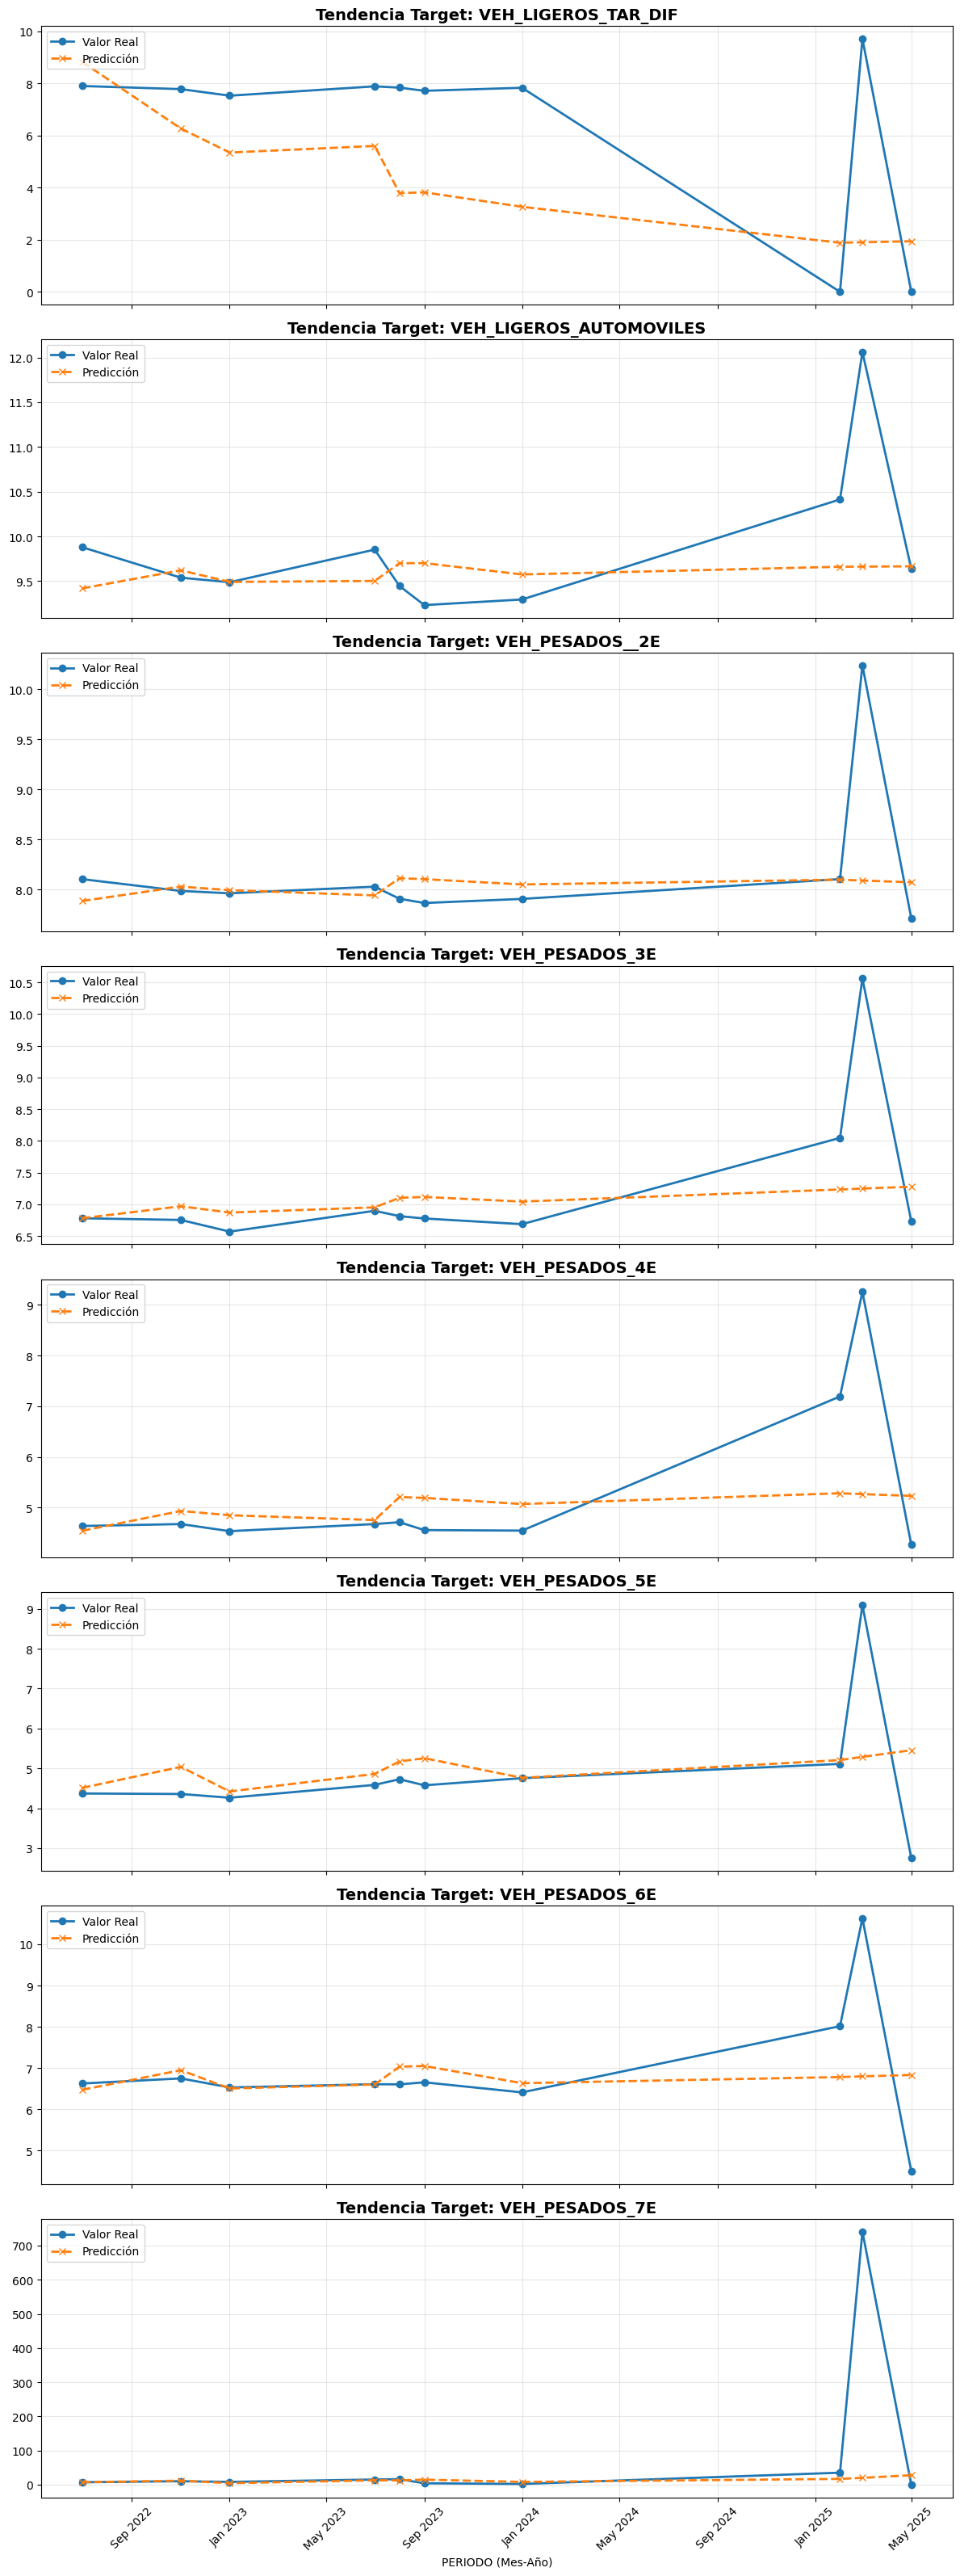

In [44]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

y_pred_log = best_model.predict(X_test_pre)
y_pred_final = np.expm1(y_pred_log)

def graficar( X_test, y_test, y_pred_final):
    df_grafico = pd.DataFrame()
    
    df_grafico['FECHA'] = pd.to_datetime(
        X_test['PERIODO'].astype(float).astype(int).astype(str), 
        format='%Y%m'
    )
    
    for i, col in enumerate(y_test.columns):
        df_grafico[f'Real_{col}'] = y_test[col].apply(np.expm1).values
        df_grafico[f'Pred_{col}'] = y_pred_final[:, i]
    
    df_grafico = df_grafico.sort_values('FECHA')
    
    #df_grafico = df_grafico[(df_grafico['FECHA'] >= '2020-01-01') & (df_grafico['FECHA'] <= '2021-12-01')]
    
    fig, axes = plt.subplots(nrows=len(y_test.columns), ncols=1, figsize=(12, 4 * len(y_test.columns)), sharex=True)
    
    if len(y_test.columns) == 1:
        axes = [axes]
    
    for i, col in enumerate(y_test.columns):
        axes[i].plot(df_grafico['FECHA'], df_grafico[f'Real_{col}'], 
                     label='Valor Real', marker='o', color='#1f77b4', linewidth=2)
        
        axes[i].plot(df_grafico['FECHA'], df_grafico[f'Pred_{col}'], 
                     label='Predicción', marker='x', color='#ff7f0e', linestyle='--', linewidth=2)
        
        axes[i].set_title(f'Tendencia Target: {col}', fontsize=14, fontweight='bold')
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        axes[i].legend(loc='upper left')
        axes[i].grid(True, alpha=0.3)
    
    plt.xticks(rotation=45)
    plt.xlabel('PERIODO (Mes-Año)')
    plt.tight_layout()
    plt.show()

graficar(X_test, y_test, y_pred_final)


### Reajustamos la lógica para que el forecast se realice de manera individual por peaje.

In [ ]:
peajes_name = data_p['CODIGO_PEAJE'].unique()

preprocessor_2 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), list(df_cat.columns)),
    ], remainder='passthrough')

# Pipeline base
pipe_model_2 = Pipeline([
    ('scaler', 'Passthrough'),
    ('model', LinearRegression())
])

# Generamos los parametros a probar en paramgrid
param_grid_2 = [
    {
        'model': [LinearRegression()],
        'scaler' : [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    {
        'model': [RandomForestRegressor()],
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 10, 20, 30],
        'scaler' : ['passthrough']
    },
    {
        'model': [XGBRegressor()],
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 10, 20, 30],
        'scaler' : ['passthrough']
    },
    {
        'model': [SVR()],
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf'],
        'scaler' : [StandardScaler(), MinMaxScaler()]
    }
]

grid_2 = GridSearchCV(pipe_model_2, param_grid_2, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

for peaje in peajes_name:
    data_temp = data_p[data_p['CODIGO_PEAJE'] == peaje]

    if not data_temp.empty:
        X = data_temp.drop(targets, axis=1)
        y = data_temp[targets]

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Formateamos las entradas
        X_train_pre = preprocessor_2.fit_transform(X_train)
        X_test_pre = preprocessor_2.transform(X_test)

        for t in targets:
            y_train[t] = y_train[t].apply(np.log1p)
            y_test[t] = y_test[t].apply(np.log1p)

        grid_2.fit(X_train_pre, y_train)

        best_model = grid_2.best_estimator_
        y_pred_log = best_model.predict(X_test_pre)

        y_pred_final = np.expm1(y_pred_log)
        y_test_original = np.expm1(y_test) # El original sin logaritmo

        print(f"Mejor Modelo: {grid_2.best_params_['model']}, peaje: {peaje}")

        from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

        rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_final))
        print(f"RMSE: {rmse:.2f}")

        mae = mean_absolute_error(y_test_original, y_pred_final)
        print(f"MAE:  {mae:.2f}")

        r2 = r2_score(y_test_original, y_pred_final)
        print(f"R2:   {r2:.4f}")

        mape = mean_absolute_percentage_error(y_test_original, y_pred_final)
        print(f"MAPE: {mape * 100:.2f}%")

        print("="*15)

        graficar(X_test, y_test, y_pred_final)

        


Mejor Modelo: RandomForestRegressor(n_estimators=200), peaje: 22PE5NACS1
RMSE: 9.73
MAE:  2.00
R2:   0.6260
MAPE: 17766249687414322.00%
Mejor Modelo: RandomForestRegressor(max_depth=10), peaje: 04PE1SCAM1
RMSE: 57.49
MAE:  6.01
R2:   0.0835
MAPE: 1991952296029962.50%
Mejor Modelo: LinearRegression(), peaje: 21PE3SCRO1
RMSE: 8.09
MAE:  2.82
R2:   0.3242
MAPE: 119346207086993056.00%
Mejor Modelo: RandomForestRegressor(max_depth=10, n_estimators=200), peaje: 12PE3NCRA1
RMSE: 61.70
MAE:  7.11
R2:   0.7754
MAPE: 20428007262824592.00%
Mejor Modelo: RandomForestRegressor(n_estimators=300), peaje: 08PE3SCSC1
RMSE: 7.54
MAE:  1.96
R2:   0.4555
MAPE: 4978769173725466.00%
Mejor Modelo: RandomForestRegressor(max_depth=10), peaje: 13PE1NCMA1
RMSE: 13.56
MAE:  2.91
R2:   0.7523
MAPE: 10724809582328682.00%
Mejor Modelo: RandomForestRegressor(max_depth=20, n_estimators=300), peaje: 15PE1SCLA1
RMSE: 78.05
MAE:  9.90
R2:   0.8374
MAPE: 9521610055882402.00%
Mejor Modelo: RandomForestRegressor(max_depth=3

In [39]:
X_train_pre.shape

(102, 0)

In [ ]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X